# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    print('Downloading the course resources...')
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
else:
    print('Using the existing course folder; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 13</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Mini-GPT desde cero</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/13_mini_gpt_desde_cero_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Cómo se integran los componentes de un decoder para construir un modelo de lenguaje autoregresivo mínimo?

En el notebook 12 estudiamos el bloque decoder como una unidad apilable que conserva la forma $(B,T,C)$. En este notebook conectamos ese bloque con embeddings de tokens, embeddings posicionales, normalización final y una cabeza de lenguaje para producir logits sobre el vocabulario.

La pregunta es necesaria porque un bloque Transformer aislado no es todavía un modelo de lenguaje: falta definir cómo entran los índices discretos, cómo se obtiene una predicción por posición y cómo se calcula una pérdida cuando se conocen los tokens objetivo.


## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar cómo un mini-GPT conecta índices de tokens con logits sobre un vocabulario.
2. Construir una instancia mínima de `MiniTransformerLM` y auditar sus formas tensoriales principales.
3. Contar parámetros por componente y relacionarlos con vocabulario, dimensión de embedding, número de capas y número de cabezas.
4. Interpretar la forma de los logits $(B,T,|\mathcal V|)$ y la pérdida de cross-entropy por token.
5. Distinguir logits, probabilidades, pérdida y selección/generación posterior.
6. Distinguir una arquitectura ejecutable de un modelo entrenado con comportamiento lingüístico significativo.

## Marco conceptual

Un mini-GPT es un Transformer decoder usado como modelo de lenguaje autoregresivo. Su entrada no es texto directamente, sino una matriz de índices enteros que provienen de una tokenización previa. Cada índice consulta una fila de una tabla de embeddings de tokens; cada posición consulta además una fila de una tabla de embeddings posicionales. La suma de ambas representaciones produce el tensor que entra a los bloques decoder.

La arquitectura completa se puede entender como una cadena de decisiones de modelado:

- Los **índices** representan tokens del vocabulario, no magnitudes semánticas.
- Los **embeddings** convierten esos índices en vectores entrenables de dimensión $C$.
- Los **bloques decoder** mezclan contexto permitido mediante atención causal y transforman canales mediante MLP.
- La **normalización final** estabiliza la representación antes de proyectarla al vocabulario.
- La **cabeza de lenguaje** (`lm_head`) transforma cada vector contextual en logits sobre los $V$ tokens posibles.

La idea central no es que el modelo ya sepa escribir, sino que la arquitectura queda preparada para aprender la tarea de predicción del siguiente token. Antes de entrenar, sus salidas son coherentes en forma y cálculo, pero no en contenido lingüístico.


## Idea visual: de índices a logits

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/13_mini_gpt_desde_cero.png" alt="Mini-GPT desde cero" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura resume el recorrido arquitectónico: índices de entrada, embeddings, bloques decoder, normalización final y logits. La lectura importante es que la dimensión interna $C$ se mantiene durante los bloques, pero al final se proyecta hacia $|\mathcal V|$, el tamaño del vocabulario.

En esta figura, `Vocab` significa vocabulario. No es el tensor de valores `V` usado dentro de la atención.

## Formulación matemática

Sea $B$ el tamaño del batch, $T$ la longitud de contexto, $|\mathcal V|$ el tamaño del vocabulario, $C$ la dimensión de embedding, $L$ el número de bloques decoder, $h$ el número de cabezas y $\theta$ el conjunto de parámetros entrenables del modelo.

La entrada del modelo es una matriz de índices:

$$
X_{ids}\in \{0,1,\dots,|\mathcal V|-1\}^{B\times T}.
$$

Esta ecuación se lee así: cada fila del batch contiene una secuencia de $T$ posiciones, y cada posición guarda el identificador entero de un token del vocabulario.

El primer paso convierte índices en vectores y añade información posicional:

$$
X^{(0)} = E_{tok}[X_{ids}] + E_{pos}[0:T],
\qquad X^{(0)}\in\mathbb{R}^{B\times T\times C}.
$$

Esta ecuación se lee así: cada token obtiene un vector de contenido y cada posición obtiene un vector de orden; ambos tienen dimensión $C$, por eso pueden sumarse.

La traza arquitectónica completa es:

$$
X_{ids}
\rightarrow E_{tok}+E_{pos}
\rightarrow \operatorname{dropout}
\rightarrow \operatorname{DecoderBlocks}_{1:L}
\rightarrow \operatorname{LN}_{f}
\rightarrow \operatorname{lm\_head}
\rightarrow Z.
$$

Esta ecuación se lee así: los índices discretos se convierten en representaciones continuas, los bloques decoder las contextualizan, la normalización final estabiliza la escala y `lm_head` produce puntajes sobre el vocabulario.

Los bloques conservan la interfaz interna:

$$
H = \operatorname{DecoderBlocks}_{\theta}(X^{(0)}),
\qquad H\in\mathbb{R}^{B\times T\times C}.
$$

Esta ecuación se lee así: los bloques cambian la representación contextual, pero conservan la forma $(B,T,C)$ para que varias capas puedan apilarse.

La cabeza de lenguaje proyecta cada posición al vocabulario:

$$
Z = \operatorname{lm\_head}(\operatorname{LN}_{f}(H)),
\qquad Z\in\mathbb{R}^{B\times T\times |\mathcal V|}.
$$

Esta ecuación se lee así: para cada ejemplo y cada posición, el modelo produce un vector de $|\mathcal V|$ puntajes. Esos puntajes son `logits`: no son texto ni probabilidades todavía.

La separación conceptual es:

$$
\text{logits } Z_{b,t,:}
\xrightarrow{\operatorname{softmax}}
\text{distribución } p_{b,t,:}
\xrightarrow{\text{selección posterior}}
\text{token elegido}.
$$

Esta ecuación se lee así: primero aparecen puntajes, después una distribución sobre el vocabulario y solo en una etapa posterior se decide cómo seleccionar un token. En este notebook se audita la arquitectura y la pérdida; la generación queda para después.

Cuando existen objetivos $Y\in\{0,1,\dots,|\mathcal V|-1\}^{B\times T}$, la pérdida promedio por token es:

$$
\mathcal{L}(\theta)=
-\frac{1}{BT}\sum_{b=1}^{B}\sum_{t=1}^{T}
\log p_\theta\left(Y_{b,t}\mid X_{b,\leq t}\right).
$$

Esta ecuación se lee así: en cada posición se penaliza al modelo si asigna baja probabilidad al token objetivo observado. En PyTorch, `cross_entropy` recibe logits de forma conceptual $(B\cdot T,|\mathcal V|)$ y targets de forma $(B\cdot T)$; no necesita que calculemos softmax manualmente.

## Traducción tensorial

La arquitectura tiene dos contratos tensoriales centrales. Primero, los índices $(B,T)$ se convierten en representaciones $(B,T,C)$. Segundo, la cabeza final cambia la última dimensión de $C$ a $|\mathcal V|$, produciendo logits $(B,T,|\mathcal V|)$.

En este notebook se verifican seis objetos computacionales:

1. `idx`: matriz de índices de entrada.
2. `targets`: matriz de tokens objetivo con la misma forma que `idx`.
3. `E_tok(idx) + E_pos`: entrada continua de forma `(B,T,C)`.
4. `blocks`: pila decoder que conserva `(B,T,C)`.
5. `logits`: puntajes por posición y por token del vocabulario.
6. `loss`: cross-entropy media sobre las $B\times T$ posiciones.

La palabra `Vocab` se usará en las tablas para recordar que el último eje de `logits` es tamaño de vocabulario, no el tensor de valores `V` de atención.

## Preparación del entorno


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore", message="Pandas requires version .*", category=UserWarning)
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.componentes_interactivos as componentes_interactivos
import fundamentos_transformers.minigpt_experimentos as minigpt_experimentos
import fundamentos_transformers.visualizacion as visualizacion

componentes_interactivos = importlib.reload(componentes_interactivos)
minigpt_experimentos = importlib.reload(minigpt_experimentos)
visualizacion = importlib.reload(visualizacion)

crear_explorador_mini_gpt = componentes_interactivos.crear_explorador_mini_gpt
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento: construir y auditar un mini-GPT

El experimento usa un vocabulario sintético pequeño para observar la arquitectura sin depender todavía de un corpus real. El objetivo no es producir texto útil, sino verificar que el modelo transforma índices en logits y que la pérdida se puede calcular contra objetivos de la misma forma $(B,T)$.


In [2]:
resultado_config = minigpt_experimentos.preparar_configuracion_minigpt()
CONFIG = resultado_config.config
model = resultado_config.model

mostrar_tablas_en_columnas(
    [
        ("Configuración", resultado_config.configuracion),
        ("Restricciones de lectura", resultado_config.restricciones),
    ]
)


parametro,valor,interpretacion
vocab_size,20.0,numero de tokens posibles en la salida
block_size,8.0,longitud maxima de contexto
n_embd,16.0,dimension interna C
n_head,4.0,cabezas de atencion por bloque
n_layer,2.0,bloques decoder apilados
dropout,0.0,desactivado para inspeccion deterministica
restriccion,valor,lectura
C = H·D,16 = 4·4,las cabezas dividen canales
T <= block_size,T <= 8,la tabla posicional tiene longitud finita
dropout=0,si,las filas de atencion se pueden leer sin ruido


La siguiente celda construye un batch sintético. `idx` representa el contexto disponible en cada posición y `targets` representa el token que se quiere predecir en esa posición. En un corpus real, estos pares se derivan de ventanas consecutivas de texto tokenizado.


In [3]:
resultado_batch = minigpt_experimentos.preparar_batch_sintetico_minigpt()
idx = resultado_batch.idx
targets = resultado_batch.targets

mostrar_tablas_en_columnas(
    [
        ("Primeras posiciones del batch", resultado_batch.batch.head(12)),
        ("Formas del batch", resultado_batch.formas),
    ]
)


ejemplo,posicion,"idx[b,t]","target[b,t]",lectura
0,0,1,2,target es el token observado que se penaliza en esa posicion
0,1,2,3,target es el token observado que se penaliza en esa posicion
0,2,3,4,target es el token observado que se penaliza en esa posicion
0,3,4,5,target es el token observado que se penaliza en esa posicion
0,4,5,6,target es el token observado que se penaliza en esa posicion
0,5,6,7,target es el token observado que se penaliza en esa posicion
0,6,7,8,target es el token observado que se penaliza en esa posicion
0,7,8,0,target es el token observado que se penaliza en esa posicion
1,0,3,4,target es el token observado que se penaliza en esa posicion
1,1,4,5,target es el token observado que se penaliza en esa posicion


Ahora se ejecuta el forward pass. Si `return_attention=True`, el modelo devuelve también los pesos de atención de la primera capa, lo que permite verificar que el mini-GPT conserva la estructura causal estudiada en notebooks anteriores.


In [4]:
resultado_forward = minigpt_experimentos.preparar_forward_minigpt(model, CONFIG, idx, targets)
logits = resultado_forward.logits
loss = resultado_forward.loss
attention = resultado_forward.attention

mostrar_tablas_en_columnas(
    [
        ("Auditoría interna", resultado_forward.traza),
        ("Verificaciones", resultado_forward.verificaciones),
        ("Pérdida y escala", resultado_forward.perdida),
    ],
    min_width="330px",
)


## Conteo de parámetros por componente

El conteo de parámetros permite leer qué decisiones arquitectónicas tienen más efecto. `vocab_size` afecta la tabla de tokens y `lm_head`; `block_size` afecta la tabla posicional; `n_layer` multiplica bloques; y $C$ aparece en casi todas las matrices internas.

In [5]:
resultado_parametros = minigpt_experimentos.preparar_parametros_minigpt(model)

mostrar_tablas_en_columnas(
    [
        ("Parámetros por componente", resultado_parametros.parametros),
        ("Lectura de decisiones", resultado_parametros.decisiones),
    ],
    min_width="360px",
)


## Explorador interactivo de arquitectura

Use los controles para cambiar decisiones estructurales y observe qué formas y conteos se alteran. La intención no es encontrar una configuración óptima, sino reconocer qué parte de la arquitectura se mueve cuando cambia `Vocab`, `block_size`, `C`, `H` o `L`.

In [6]:
crear_explorador_mini_gpt()

## Inspección de logits, probabilidades y pérdida local

Los logits son la salida directa del modelo. Para interpretarlos como una distribución se aplica softmax sobre el eje `Vocab`. La pérdida usa el target observado de la posición, pero eso no significa que el modelo esté obligado a escoger siempre el token más probable durante generación; esa decisión depende de una estrategia posterior de selección.

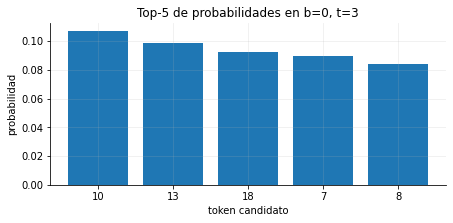

In [7]:
resultado_logits = minigpt_experimentos.preparar_inspeccion_logits(logits, targets, b_sel=0, t_sel=3)

mostrar_tablas_en_columnas(
    [
        ("Top-5 de la distribución", resultado_logits.top_tokens),
        ("Target y pérdida local", resultado_logits.objetivo),
        ("Lectura por pasos", resultado_logits.pasos),
    ],
    min_width="300px",
)

display(resultado_logits.figura)
plt.close(resultado_logits.figura)


## Interpretación

El experimento muestra que el mini-GPT ya tiene una interfaz completa de modelo de lenguaje: recibe índices, produce logits por posición y permite calcular una pérdida contra targets. Sin embargo, como los pesos no han sido entrenados con un corpus, la distribución observada no debe interpretarse como conocimiento lingüístico.

La salida de la cabeza final no genera texto por sí sola. Para generar texto habría que convertir logits en probabilidades, seleccionar un token y realimentarlo como parte del contexto. Ese ciclo pertenece al entrenamiento y la generación autoregresiva, no a la simple construcción arquitectónica.


## Verificación de aprendizaje

Modifique una sola variable de la configuración: `vocab_size`, `block_size`, `n_embd`, `n_head` o `n_layer`. Ejecute la comparación y explique con evidencia cuál forma tensorial o conteo de parámetros cambia.

Para que la respuesta sea válida, conecte tres niveles: decisión arquitectónica, tensor afectado y consecuencia observada. Por ejemplo: “al aumentar `vocab_size`, cambia el último eje de `logits` $(B,T,|\mathcal V|)$ y también aumentan `token_embedding` y `lm_head`”.

La consigna no es buscar una configuración “mejor”, sino aislar el efecto estructural de cada decisión.

In [8]:
resultado_variantes = minigpt_experimentos.preparar_variantes_minigpt(CONFIG)

mostrar_tablas_en_columnas(
    [
        ("Variantes controladas", resultado_variantes.variantes),
        ("Lectura", resultado_variantes.lectura),
    ],
    min_width="360px",
)


## Análisis crítico

**Qué ocurrió.** El modelo produjo logits de forma $(B,T,|\mathcal V|)$, calculó una cross-entropy media y devolvió pesos de atención de forma $(B,H,T,T)$ para la primera capa.

**Por qué ocurrió.** La arquitectura integra embeddings, posición, bloques decoder, normalización final y cabeza de lenguaje. Cada componente conserva o transforma una dimensión específica: los bloques conservan $C$, mientras que `lm_head` cambia $C$ por `Vocab`.

**Qué no se puede concluir.** Una pérdida calculable no implica que el modelo haya aprendido lenguaje. Con pesos aleatorios, las probabilidades reflejan inicialización y arquitectura, no patrones de un corpus. Tampoco se puede concluir calidad generativa, coherencia sintáctica ni conocimiento factual.

**Lectura cuidadosa de los logits.** Un token puede tener mayor probabilidad que el target observado en una posición sintética. Eso no contradice el entrenamiento: la pérdida solo mide qué tanta probabilidad recibió el target. En generación, elegir siempre el máximo (`argmax`) es una estrategia posible, pero también existen muestreos entre tokens probables; esa decisión se estudia más adelante.

## Síntesis

La cadena operacional del notebook es:

$$
X_{ids} \rightarrow E_{tok}+E_{pos} \rightarrow X\in\mathbb{R}^{B\times T\times C} \rightarrow \operatorname{DecoderBlocks} \rightarrow H \rightarrow \operatorname{LN}_{f} \rightarrow Z\in\mathbb{R}^{B\times T\times |\mathcal V|} \rightarrow \mathcal{L}.
$$

Esta cadena se lee así: los índices se transforman en vectores, los bloques decoder contextualizan esos vectores, la cabeza final produce logits sobre el vocabulario y la pérdida compara esos logits con los tokens objetivo.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que un mini-GPT no es una sola capa, sino una composición de decisiones representacionales y tensoriales que hacen posible entrenar por predicción del siguiente token.
</div>

## Preguntas de discusión

1. ¿Por qué el tamaño del vocabulario $V$ aparece en la última dimensión de los logits y no durante todos los bloques decoder?
2. ¿Qué diferencia matemática y computacional hay entre $C$ y $V$?
3. Si se aumenta `n_layer`, ¿qué cambia en parámetros y qué no cambia en la forma de los logits?
4. ¿Por qué una pérdida calculada con pesos aleatorios no debe interpretarse como evidencia de aprendizaje lingüístico?
5. ¿Qué componente del modelo permite pasar de representaciones internas a una distribución sobre el siguiente token?


## Continuidad

Con este notebook queda construida la arquitectura mínima de un modelo de lenguaje tipo GPT. El siguiente paso es entrenarla con datos secuenciales: construir batches autoregresivos, aplicar optimización, observar curvas de pérdida y evaluar qué aprende o no aprende el modelo bajo una configuración pequeña.
